# Projet : Prédiction des retards de vols

Analyse exploratoire, préparation des données et comparaison de deux modèles prédictifs (Régression Logistique vs Random Forest) sur le dataset `Airlines.csv`.

## 1. Imports & Chargement

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

In [27]:
df=pd.read_csv('Airlines.csv')

## 2. Exploration

In [31]:
df.head()
#df.describe()
#df.info()

,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 539383 entries, 0 to 539382
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   id           539383 non-null  int64
 1   Airline      539383 non-null  str  
 2   Flight       539383 non-null  int64
 3   AirportFrom  539383 non-null  str  
 4   AirportTo    539383 non-null  str  
 5   DayOfWeek    539383 non-null  int64
 6   Time         539383 non-null  int64
 7   Length       539383 non-null  int64
 8   Delay        539383 non-null  int64
dtypes: int64(6), str(3)
memory usage: 37.0 MB


## 3. Visualisation

In [51]:
jours= df['DayOfWeek'].value_counts()

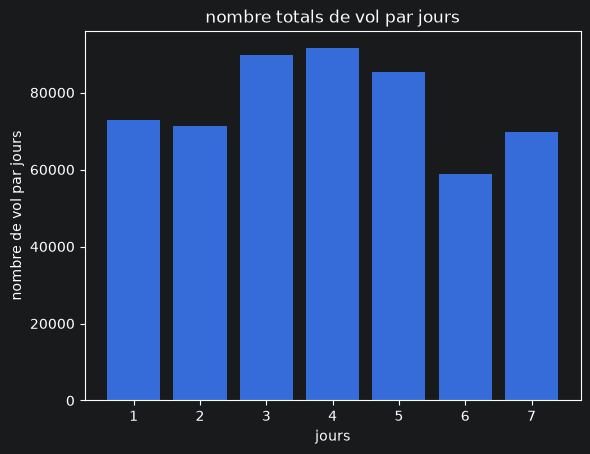

In [52]:
plt.bar(jours.index,jours.values)
plt.title("nombre totals de vol par jours")
plt.xlabel("jours")
plt.ylabel("nombre de vol par jours")
plt.show()

In [54]:
affiche_retard= df['Delay'].value_counts()

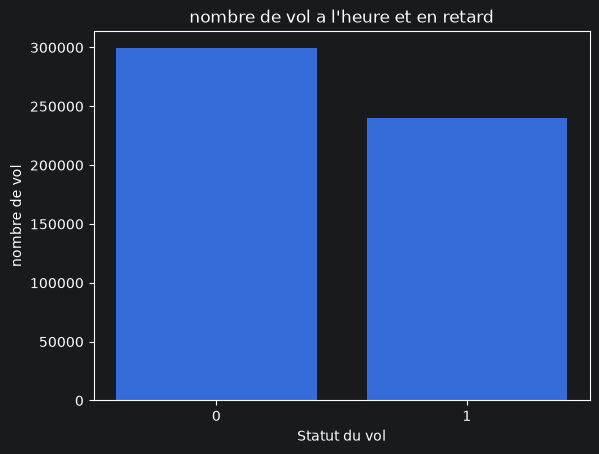

In [56]:
plt.bar(affiche_retard.index,affiche_retard.values)
plt.title("nombre de vol a l'heure et en retard")
plt.xlabel("Statut du vol")
plt.xticks([0, 1])
plt.ylabel("nombre de vol")
plt.show()


## 4. Filtrage des retards

In [18]:
df[df['Delay']==0]

,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
4,5,AS,108,ANC,SEA,3,30,202,0
6,7,DL,1768,LAX,MSP,3,30,220,0
7,8,DL,2722,PHX,DTW,3,30,228,0
12,13,DL,2055,SLC,ATL,3,50,210,0
13,14,AA,2408,LAX,DFW,3,55,170,0
...,...,...,...,...,...,...,...,...,...
539374,539375,DL,2354,LAX,ATL,5,1435,255,0
539375,539376,FL,58,LAX,ATL,5,1435,250,0
539378,539379,CO,178,OGG,SNA,5,1439,326,0
539379,539380,FL,398,SEA,ATL,5,1439,305,0


In [19]:
df_retard=df[df['Delay']==1]

In [21]:
df_retard

,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
5,6,CO,1094,LAX,IAH,3,30,181,1
...,...,...,...,...,...,...,...,...,...
539373,539374,B6,480,LAX,BOS,5,1435,320,1
539376,539377,B6,717,JFK,SJU,5,1439,220,1
539377,539378,B6,739,JFK,PSE,5,1439,223,1
539381,539382,UA,78,HNL,SFO,5,1439,313,1


## 5. Analyse des routes

In [63]:
routes_retard=df_retard[['AirportFrom','AirportTo']].value_counts().head(10)

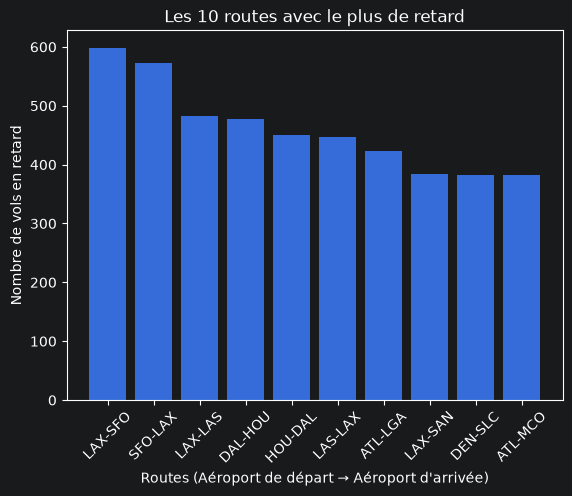

In [66]:
labels = [f"{depart}-{arrivee}" for depart, arrivee in routes_retard.index]
plt.bar(labels, routes_retard.values)
plt.title("Les 10 routes avec le plus de retard")
plt.xlabel("Routes (Aéroport de départ → Aéroport d'arrivée)")
plt.xticks(rotation=45)
plt.ylabel("Nombre de vols en retard")
plt.show()

## 6. Taux de retard par route

In [40]:
taux_retard=df.groupby(["AirportFrom","AirportTo"])["Delay"].mean()

In [67]:
df_vol=df.groupby(["AirportFrom","AirportTo"]).size()

In [44]:
print(taux_retard.sort_values(ascending=False))


AirportFrom  AirportTo
DTW          HPN          1.0
             HNL          1.0
             ICT          1.0
PIT          CRW          1.0
LAS          BUF          1.0
                         ... 
PIA          MSP          0.0
HPN          DTW          0.0
ROC          RSW          0.0
RSW          ROC          0.0
EGE          LGA          0.0
Name: Delay, Length: 4190, dtype: float64


In [45]:
print(df_vol.sort_values(ascending=False))

AirportFrom  AirportTo
LAX          SFO          1079
SFO          LAX          1077
OGG          HNL           982
HNL          OGG           951
SAN          LAX           935
                          ... 
EWR          PWM             1
HPN          DTW             1
DTW          HPN             1
IDA          PIH             1
BFL          SBP             1
Length: 4190, dtype: int64


## 7. Corrélations

In [69]:
df_correlation=df.corr(numeric_only=True)

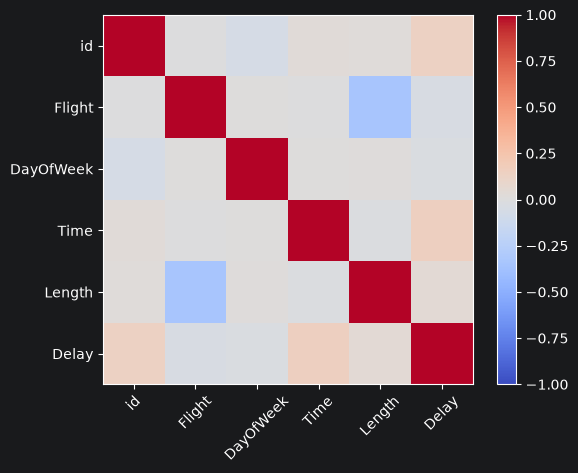

In [72]:
plt.imshow(df_correlation, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(df_correlation.columns)), df_correlation.columns,rotation=45)
plt.yticks(range(len(df_correlation.columns)), df_correlation.columns)
plt.colorbar()
plt.show()

In [49]:
df.corr(numeric_only=True)["Delay"]

id           0.139762
Flight      -0.046175
DayOfWeek   -0.026199
Time         0.150454
Length       0.040489
Delay        1.000000
Name: Delay, dtype: float64

## 8. Encodage

In [74]:
Le_Airline = LabelEncoder()
Le_AirportFrom = LabelEncoder()
Le_AirportTo = LabelEncoder()

df["Airline_encoder"]=Le_Airline.fit_transform(df["Airline"])
df["AirportFrom_encoder"]=Le_AirportFrom.fit_transform(df["AirportFrom"])
df["AirportTo_encoder"]=Le_AirportTo.fit_transform(df["AirportTo"])

In [75]:
df.corr(numeric_only=True)["Delay"]

id                     0.139762
Flight                -0.046175
DayOfWeek             -0.026199
Time                   0.150454
Length                 0.040489
Delay                  1.000000
Airline_encoder        0.066936
AirportFrom_encoder    0.018459
AirportTo_encoder      0.047990
Name: Delay, dtype: float64

## 9. Préparation du modèle

In [78]:
X=df[['Time' ,'Airline_encoder','Length','DayOfWeek','AirportFrom_encoder', 'AirportTo_encoder']]
y=df['Delay']

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

## 10. Régression Logistique

In [ ]:
LR_train=LogisticRegression()
LR_train.fit(X_train, y_train);

In [90]:
y_pred_train= LR_train.predict(X_test)
accuracy_score(y_test,y_pred_train,normalize=True)

0.5806056898133986

## 11. Random Forest

In [100]:
clf = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')

In [ ]:
clf.fit(X_train, y_train);

In [102]:
y_pred_forest = clf.predict(X_test)
accuracy_score(y_test, y_pred_forest, normalize=True)

0.6109643390157309

In [103]:
confusion_matrix(y_test, y_pred_forest)

array([[36962, 22917],
       [19051, 28947]])